In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import numpy
import pylab as plt
import scipy
import math
import PIL
import os
import time
import h5py
import glob

# IO ML (and other operations too...) analysis
The basic objective here is to examine some different ways to handle IO for ML applications and to evaluate the performance of different strategies and tools. The process is to:
- Load up some data, by a variety of IO methods
- Do something analytical to it.
- In this case, it might be a toy problem -- like taking some eigen values or some other linear algebra foo.
- Evaluate the speed performance of the different IO methods.

In principle, we can (should?) skip the analytical step entirely, since our objective is to evaluate the cost of IO. However, processors and even interpreted languages these days can be very tricky about recognizing a step that actually performs no work, so we (hope to...) force the program to actually load the data into memory by executing a toy operation.

It is a short exercise, left to the user, to show that for more intensse computational tasks, the choice of IO model becomes less relevant -- because the CPU-bound compute step is much longer. Consider, however, that the whole point of using GPUs is to speed up that step, so a job that is prototyped on CPUs, the choice of IO will be _much_ more significant when the principal compute steps are offloaded to GPU. It may also be desirable to review the offloading step itself. In particular, where these examples likley offload one row of data at a time, it may be possible to offload much larger blocks of data, better capitalizing on GPU memory and other caches.


We will examine the cases where data are loaded:
- From a single text file
- From an HDF5 array, which is
  - Read line-by-line, `for rw in h5_obj[dataset]`
  - Read into an array, then `for rw in read_array:`
- Reading each data array from an individual (small...) file.

In this case, we are using standard text character data, used to train OCR models.

DataSet(s):
- Kaggel EMNIST character set (hand written and typed font)
- I think this is the dataset:
  - https://www.kaggle.com/datasets/crawford/emnist?resource=download
  - But really, any character data set will do, with the exception that the image sizes and dimensions might vary.

## Process:
- Download the Kaggel, or some other, data set.
- This can be done manually, or using the kaggle API, eg:
```
import kagglehub

# Download latest version
path = kagglehub.dataset_download("crawford/emnist")

print("Path to dataset files:", path)
```
- Then, of course, it may be necessary to set up the directories correctly. Later versions of this notebook might scrip this out more rigorously.
- Build any modified data repositories:
  - Original `.csv`
  - HDF5
  - Bunch-o-little-files


## Data paths and pre-process data repos

In [3]:
# Optinally, do this to use the kaggle downloader:
# import kagglehub
# # Download latest version
# # I assume there is a parameter to specify the download target path?
# kaggle_data_path = kagglehub.dataset_download("crawford/emnist")
# print("Path to dataset files:", path)

kaggle_data_path = 'data_sets/Kaggle1_archive'
kaggel_balanced_train = os.path.join(kaggle_data_path, 'emnist-balanced-train.csv')

# Pre-process data (create derivative data storage containers)

## HDF5:
- Create an HDF5 object from a serial text file
- Pack these arrays into an HDF5 object. This will take a while, but then let's see if we can show improved compute performance.
- Probably not... since most of the time here is probably spent taking Eigen Vectors, but we can take it a step further and break out the data set into a bunch of .csv files.

In [13]:
t0 = time.time()

kaggel_balanced_train_h5 = f'{os.path.splitext(kaggel_balanced_train)[0]}.h5'
 
print('** ', kaggel_balanced_train_h5)

do_it_anyway = False

if not os.path.isfile(kaggel_balanced_train_h5) or do_it_anyway:
    with h5py.File(kaggel_balanced_train_h5, 'w') as h5_obj:
        _data = []
        with open(kaggel_balanced_train, 'r') as fin:
            for rw in fin:
                _data += [rw.split(',')]
        _data = numpy.array(_data).astype(float)
        #
        h5_obj.create_dataset("balanced_training", data=numpy.array(_data))
        del _data
    #
#
        
t1 = time.time()
print(f'** time to create HDF5: {t1-t0}')

**  data_sets/Kaggle1_archive/emnist-balanced-train.h5
** time to create HDF5: 19.282594203948975


## Bunch-o-files
- Parse primary text file into `n_rows` individual (tiny...) files
- This is not a recommended method.
- In fact, this is precisely what we are hoping to show to *not* do.


In [5]:
bof_path = f'{os.path.splitext(kaggel_balanced_train)[0]}_bof'
print(f'** bof_path[{os.path.isdir(bof_path)}]: {bof_path}')
#
# we want to be careful about doing this all the time, as it will be costly.
if not os.path.isdir(bof_path):
    print('** doing it!')
    os.makedirs(bof_path)
    #
    # how many rows are we talking about here?
    with open(kaggel_balanced_train, 'r') as fin:
        for k, rw in enumerate(fin):
            pass
        zero_pad = '0'*(1+len(str(k)))
        nzp = len(zero_pad)
        # or more mathy:
        #zero_pad2 = '0'*(int(math.log10(k)+1))
        ##
        #print(f'** zero_pad: {zero_pad}, zero_pad2: {zero_pad2}')
    with open(kaggel_balanced_train, 'r') as fin:
        for k, rw in enumerate(fin):
            index_str = f'{zero_pad}{k}'[-nzp:]
            bof_file_name = os.path.join(bof_path, f'bof_{index_str}.csv')
            with open(bof_file_name, 'w') as fout:
                fout.write(rw)
            #
            if k%1000 == 0:
                print(f'** k={k} files written.')
        
            
            

** bof_path[True]: data_sets/Kaggle1_archive/emnist-balanced-train_bof


## Have a look at some images
- What are we dealing with?
- Have a quick look at some images?
- Note, the image data (may...) be provided as integer values, but it might make more sense to cast them as floats.
- Images can probalby be (likely, will be anyway?) rendered as integers, but linear algebra will invariably convert to floats.

** ** n_images: 0/9 9
** ** n_images: 1/9 9
** ** n_images: 2/9 9
** ** n_images: 3/9 9
** ** n_images: 4/9 9
** ** n_images: 5/9 9
** ** n_images: 6/9 9
** ** n_images: 7/9 9
** ** n_images: 8/9 9


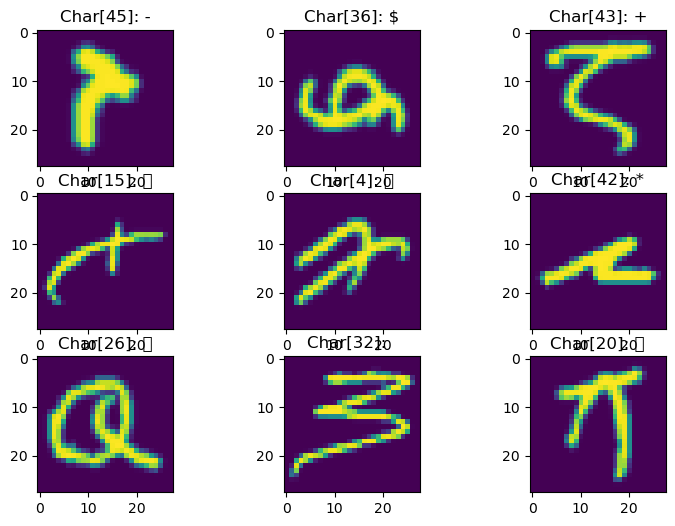

In [19]:
n_images = 9
n_cols = 3
n_rows = numpy.ceil(float(n_images)/float(n_cols)).astype(int)
#
fg = plt.figure(figsize=(3*n_cols, 2*n_rows))
#
with open(kaggel_balanced_train, 'r') as fin:
    for k,rw in enumerate(fin):
        #print(f'**[{k}]: {rw}')
        #
        # data are provided as integers, but let's cast them as floats, since that is really how we
        #. are using them. right?
        #z = numpy.array(rw.split(','))[1:].astype(int)
        z = numpy.array(rw.split(','))[1:].astype(float)
        z.shape=(28,28)
        #
        #print(f'****\n{z}')
        #
        #fg = plt.figure(figsize=(3,2))
        #ax = fg.add_subplot(1,1,1)
        ax = fg.add_subplot(n_rows, n_cols, k+1)
        ax.imshow(z)
        #print("** ** ", rw.index(','))
        s = rw[0:rw.index(",")]
        ax.set_title(f'Char[{s}]: {chr(int(s))}')
        #
        #print(f'** ** n_images: {k}/{n_images}', n_images)
        if k >= n_images-1:
            break

## Principal Analysis (-like) task
- Create a stupid problem to solve, so we can benchmark things
- Principal analysis (eigen-vectors, -values) of variance of each image
- Or something like it anyway...

In [20]:
def get_row_eigs(z_img):
    #V = numpy.array([numpy.var(z_img-x) for x in z_img])
    V = z_img
    #V -= numpy.mean(V)
    #V *= V
    return numpy.linalg.eig(V.reshape(28,28))

# def get_matrix_eigs(z_img):
#     return numpy.linalg.eig(V.reshape(28,28))

row_job = get_row_eigs

k_max = 15000
k_verbose_interval = 1000

## Try doing this by spinning through (a bunch of small) files.
- Open each file separately.
- Spoiler Alert: This will be much slower!

In [27]:
# bof_path
tm = time.time()
times = [tm]
for k, fl in enumerate(glob.glob(os.path.join(bof_path, '*'))):
    #print(f'** [{k}]: {fl}')
    #
    with open(fl, 'r') as fin:
        z_img = numpy.array(fin.read().split(',')[1:]).astype(float)
        row_work = row_job(z_img)
    #
    times += [time.time()]
    
    #
    if k%k_verbose_interval == 0:
        print(f'** [{k}]: {fl}')
    #    pass
    if not k_max is None and k>k_max:
        break
#
times = numpy.array(times)
times = times[1:]-times[:-1]

print(f'** total time: {numpy.sum(times)}')
print(f'** mean time: {numpy.mean(times)}')

** [0]: data_sets/Kaggle1_archive/emnist-balanced-train_bof/bof_0022611.csv
** [1000]: data_sets/Kaggle1_archive/emnist-balanced-train_bof/bof_0056386.csv
** [2000]: data_sets/Kaggle1_archive/emnist-balanced-train_bof/bof_0079239.csv
** [3000]: data_sets/Kaggle1_archive/emnist-balanced-train_bof/bof_0061853.csv
** [4000]: data_sets/Kaggle1_archive/emnist-balanced-train_bof/bof_0037427.csv
** [5000]: data_sets/Kaggle1_archive/emnist-balanced-train_bof/bof_0107080.csv
** [6000]: data_sets/Kaggle1_archive/emnist-balanced-train_bof/bof_0052693.csv
** [7000]: data_sets/Kaggle1_archive/emnist-balanced-train_bof/bof_0073449.csv
** [8000]: data_sets/Kaggle1_archive/emnist-balanced-train_bof/bof_0020561.csv
** [9000]: data_sets/Kaggle1_archive/emnist-balanced-train_bof/bof_0064519.csv
** [10000]: data_sets/Kaggle1_archive/emnist-balanced-train_bof/bof_0022982.csv
** [11000]: data_sets/Kaggle1_archive/emnist-balanced-train_bof/bof_0057449.csv
** [12000]: data_sets/Kaggle1_archive/emnist-balanced

## Read one big text file
- Data are `.csv` formatted
- But at least consolidated into one file, which we can leave open while we read it.

In [21]:
# tm = time.time()
# times = [tm]
# with open(kaggel_balanced_train, 'r') as fin:
#     #
#     # I think this still needs some splitting...
#     Z = numpy.array(fin.read()).astype(float)
#     Z = Z[:,1:]

In [22]:
tm = time.time()
times = [tm]
with open(kaggel_balanced_train, 'r') as fin:
    for k,rw in enumerate(fin):
        #print(f'**[{k}]: {rw}')
        z = numpy.array(rw.split(',')).astype(float)
        # NOTE First element is some sort of index.
        z_img = z[1:]
        #
        # variance array:
        #V = numpy.array([numpy.var(z_img-x) for x in z_img])
        #print(f'** Shape [{k}]: {V.shape}')
        #eigs = numpy.linalg.eig(V.reshape(28,28))
        #
        #eigs = get_row_eigs(z_img)
        row_work = row_job(z_img)
        #
        times += [time.time()]
        #
        if k%k_verbose_interval == 0:
            print(f'** k={k}')
        
        
        if not k_max is None and k>k_max:
            break
times = numpy.array(times)
times = times[1:]-times[:-1]
#
print(f'** total time: {numpy.sum(times)}')
print(f'** mean time: {numpy.mean(times)}')
#print(f'** times: {times}')

** k=0
** k=1000
** k=2000
** k=3000
** k=4000
** k=5000
** k=6000
** k=7000
** k=8000
** k=9000
** k=10000
** k=11000
** k=12000
** k=13000
** k=14000
** k=15000
** total time: 3.2697110176086426
** mean time: 0.00021795167428400496


## HDF5: Spin through the dataset directly

In [23]:
tm = time.time()
times = [tm]
with h5py.File(kaggel_balanced_train_h5, 'r') as fin:
    for k,rw in enumerate(fin['balanced_training']):
        #print(f'**[{k}]: {rw}')
        #
        z_img = rw[1:]
        #
        # variance array:
        #V = numpy.array([numpy.var(z_img-x) for x in z_img])
        #print(f'** Shape [{k}]: {V.shape}')
        #eigs = numpy.linalg.eig(V.reshape(28,28))
        #
        #eigs = get_row_eigs(z_img)
        row_work = row_job(z_img)
        #
        #print('** evals:', ','.join([str(x) for x in eigs[0][0:4]]) )
        #times += [time.time()-times[-1]]
        times += [time.time()]
        #
        if k%k_verbose_interval == 0:
            print(f'** k={k}')
        #
        if not k_max is None and k>k_max:
            break
times = numpy.array(times)
times = times[1:]-times[:-1]

print(f'** total time: {numpy.sum(times)}')
print(f'** mean time: {numpy.mean(times)}')

** k=0
** k=1000
** k=2000
** k=3000
** k=4000
** k=5000
** k=6000
** k=7000
** k=8000
** k=9000
** k=10000
** k=11000
** k=12000
** k=13000
** k=14000
** k=15000
** total time: 0.9574699401855469
** mean time: 6.382281963641827e-05


## Read array from HDF5, then spin array

In [24]:
tm = time.time()
times = [tm]
with h5py.File(kaggel_balanced_train_h5, 'r') as fin:
    ZZ = fin['balanced_training'][:]
    print('** ', len(ZZ))
    print('** ', ZZ.shape)
    
    
#for k,rw in enumerate(fin['balanced_training']):
for k,rw in enumerate(ZZ):
    #print(f'**[{k}]: {rw}')
    #
    z_img = rw[1:]
    #
    # variance array:
    #V = numpy.array([numpy.var(z_img-x) for x in z_img])
    #print(f'** Shape [{k}]: {V.shape}')
    #eigs = numpy.linalg.eig(V.reshape(28,28))
    #
    #eigs = get_row_eigs(z_img)
    row_work = row_job(z_img)
    #
    #print('** evals:', ','.join([str(x) for x in eigs[0][0:4]]) )
    #times += [time.time()-times[-1]]
    times += [time.time()]
    #
    if k%k_verbose_interval == 0:
        print(f'** k={k}')


    if not k_max is None and k>k_max:
        break
times = numpy.array(times)
times = times[1:]-times[:-1]

print(f'** total time: {numpy.sum(times)}')
print(f'** mean time: {numpy.mean(times)}')

**  112800
**  (112800, 785)
** k=0
** k=1000
** k=2000
** k=3000
** k=4000
** k=5000
** k=6000
** k=7000
** k=8000
** k=9000
** k=10000
** k=11000
** k=12000
** k=13000
** k=14000
** k=15000
** total time: 0.9428479671478271
** mean time: 6.284815138966985e-05


In [ ]:
fls = glob.glob(f'{path}/*')
for fl in fls:
    print('** ', fl)